# Project imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from datetime import datetime
import time

from fontTools.merge.util import current_time

C# initialize flappy game

In [2]:
import sys
import os
os.environ['SDL_VIDEODRIVER'] = 'dummy'
sys.path.insert(0, 'itml-project2')
# noinspection PyUnresolvedReferences
from ple.games.flappybird import FlappyBird
# noinspection PyUnresolvedReferences
from ple import PLE

pygame 2.6.1 (SDL 2.28.4, Python 3.13.0)
Hello from the pygame community. https://www.pygame.org/contribute.html
couldn't import doomish


In [3]:
class PPO_Flappy(nn.Module):

    def __init__(self,num_layers,layer_specs):
        super().__init__()

        self.layers = nn.ModuleList()
        for i in range(num_layers):
                self.layers.append(nn.Linear(layer_specs[i][0],layer_specs[i][1]))


        self.actor = nn.Linear(layer_specs[-1][1],2) # actor outputs a probability of jumping or doing nothing
        self.critic = nn.Linear(layer_specs[-1][1],1) # critic outputs value for state


    def forward(self,x):

        for i in self.layers:
            x = F.tanh(i(x))

        action_prob = F.softmax(self.actor(x),dim=-1) # return action probability
        state_value = self.critic(x) # Critic assessed state value
        return action_prob,state_value




# Helper Functions

In [4]:
def normalize_game_state(state):
    means = torch.tensor([256.0, 0.0, 200.0, 200.0, 200.0, 400.0, 200.0, 200.0])
    stds = torch.tensor([128.0, 5.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0])
    return (state - means) / stds

def create_network():
    total_layers = 5
    layer_specs = [[8, 1024], [1024, 128], [128, 16], [16, 256], [256, 256]]
    return total_layers,layer_specs

def get_Advantage(states,rewards):
    # Calculating Advantage
    # Advantage = G - V(S_t),

    # V(S_t)
    with torch.no_grad():
        _,prev_values = model(states)

    # G calculations
    G = 0
    returns = [] # Real reward returns discounted
    for reward in reversed(rewards):
        G = reward + gamma*G
        G = torch.FloatTensor([G])
        returns.insert(0,G)
    returns = torch.stack(returns)

    A = (returns - prev_values).squeeze()

    return A, returns

def train_print(epoch_num,L_clip_mean,L_vf_mean,L_entr_mean,avg_reward,elapsed_time):
    print(f"Epoch: {epoch_num}, "
              f"L_clip: {L_clip_mean:.2f}, "
              f"Squared loss: {L_vf_mean:.2f}, "
              f"Entropy loss: {L_entr_mean:.2f}, "
              f"Avg Rewards: {avg_reward:.2f}, "
              f"Time elapsed: {elapsed_time:.2f}s")

def get_model_names(total_models):
    """ Generate Model names"""
    identifier = [i for i in range(total_models)]

    unique_str = datetime.now().strftime("%d-%m-%Y ")

    names = ["flappy weights/Flappy " + str(unique_str)+str(i) + ".pt" for i in identifier]
    return names

# training Loop

In [5]:
def Train_Network(epochs,print_freq):

    start_time = time.time()
    game = FlappyBird()

    total_rewards = []
    all_L_clip = []
    all_L_vf = []
    all_L_entropy = []
    stats_rows = []

    for i in range(epochs):
        done = False
        p = PLE(game, fps=30, display_screen=False, force_fps=True)
        p.init()

        log_probs = []
        rewards = []
        states = []
        actions = []

        while not done:
            game_state = normalize_game_state(torch.tensor(list(p.getGameState().values())))

            action_prob,_ = model(game_state) # get action prob from model, critic values called later

            # Actor Action
            action_prob = action_prob.detach().squeeze()
            dist = torch.distributions.Categorical(action_prob)
            action = dist.sample()

            if action == 0:
                ret_action = p.getActionSet()[0]
            else:
                ret_action = p.getActionSet()[1]

            # Acting on environment
            reward = p.act(ret_action)

            # Saving values
            log_probs.append(dist.log_prob(action))
            rewards.append(reward)
            actions.append(action)
            states.append(game_state)

            #print_state(action,state,reward)
            if p.game_over():
                done = True
                p.reset_game()


        # Storing values after game loop
        total_rewards.append(sum(rewards))
        states = torch.stack(states).squeeze()
        log_probs = torch.stack(log_probs).squeeze()
        actions = torch.stack(actions).squeeze()
        # Calculating advantage and storing returns for later
        A, returns = get_Advantage(states,rewards)


        for j in range(K_epochs):

            action_probs,new_values = model(states) # Generate new actions and values
            new_dist = torch.distributions.Categorical(action_probs) # Create distribution from new actions
            new_policy = new_dist.log_prob(actions) # Creating policy from

            ratio = torch.exp(new_policy-log_probs)
            clipped_ratio = torch.clamp(ratio,min = 1-epsilon,max= 1+epsilon)

            L_clip = (torch.min(ratio*A,clipped_ratio*A).mean())*c0
            L_vf = ((new_values.squeeze() - returns.squeeze())**2)*c1
            entropy_bonus = (new_dist.entropy())*c2

            # Accident but worked very well, squaring the coefficients
            # loss = -(c0*L_clip-c1*L_vf+c2*entropy_bonus).mean()


            loss = -(L_clip-L_vf+entropy_bonus).mean()

            all_L_clip.append(L_clip.mean().item())
            all_L_vf.append(L_vf.mean().item())
            all_L_entropy.append(entropy_bonus.mean().item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_L_clip = sum(all_L_clip[-K_epochs:]) / K_epochs
        epoch_L_vf = sum(all_L_vf[-K_epochs:]) / K_epochs
        epoch_L_entropy = sum(all_L_entropy[-K_epochs:]) / K_epochs
        stats_rows.append({
            "epoch": i + 1,
            "reward": total_rewards[-1],
            "L_clip": epoch_L_clip,
            "L_vf": epoch_L_vf,
            "L_entropy": epoch_L_entropy,
        })

        if (i+1) % print_freq == 0:
            current_time = time.time()
            elapsed_time = current_time - start_time

            epoch_num = i+1
            n_recent = int(K_epochs*print_freq)

            avg_reward = sum(total_rewards[-print_freq:]) /len(total_rewards[-print_freq:])
            L_clip_mean = sum(all_L_clip[-n_recent:]) / len(all_L_clip[-n_recent:])
            L_vf_mean = sum(all_L_vf[-n_recent:]) / len(all_L_vf[-n_recent:])
            L_entr_mean = sum(all_L_entropy[-n_recent:]) / len(all_L_entropy[-n_recent:])

            train_print(epoch_num,L_clip_mean,L_vf_mean,L_entr_mean,avg_reward,elapsed_time)

    return pd.DataFrame(stats_rows)

### Hyper paramters

In [6]:
from datetime import datetime

lr = 0.0001 # Learning Rate
epsilon = 0.1 # Clipping range
gamma = 0.99 # Reward discount factor

# Loss Coeffs
c0 = 1
c1 = 0.01
c2 = 0.1

In [7]:
total_layers,layer_specs = create_network()
model = PPO_Flappy(total_layers,layer_specs)
model.load_state_dict(torch.load('Parallel 5Mil.pt'))

<All keys matched successfully>

# Train

In [9]:
Total_runs = 1
epochs = 5000
K_epochs = 5
print_freq = 100
model_dict = {}

model_names = get_model_names(Total_runs)

total_layers,layer_specs = create_network()
print("Total layers: ",total_layers)
print(f"Layer setup: {layer_specs}")

optimizer = torch.optim.Adam(model.parameters(),lr = lr)

stats = Train_Network(epochs,print_freq)

Total layers:  5
Layer setup: [[8, 1024], [1024, 128], [128, 16], [16, 256], [256, 256]]


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Epoch: 100, L_clip: -3.15, Squared loss: 0.11, Entropy loss: 0.06, Avg Rewards: -4.93, Time elapsed: 1.85s
Epoch: 200, L_clip: -2.10, Squared loss: 0.05, Entropy loss: 0.06, Avg Rewards: -4.89, Time elapsed: 3.48s
Epoch: 300, L_clip: -0.78, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.94, Time elapsed: 5.18s
Epoch: 400, L_clip: -0.20, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.88, Time elapsed: 6.82s
Epoch: 500, L_clip: -0.57, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.91, Time elapsed: 8.58s
Epoch: 600, L_clip: -0.33, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.80, Time elapsed: 10.41s
Epoch: 700, L_clip: -0.24, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.80, Time elapsed: 12.26s
Epoch: 800, L_clip: -0.07, Squared loss: 0.01, Entropy loss: 0.06, Avg Rewards: -4.37, Time elapsed: 14.22s
Epoch: 900, L_clip: 0.28, Squared loss: 0.03, Entropy loss: 0.05, Avg Rewards: -2.66, Time elapsed: 17.40s
Epoch: 1000, L_clip: 0.67, Squared

KeyboardInterrupt: 

### Plot stats

/var/folders/t_/027538rx2yg32by5y5v2x46c0000gn/T/ipykernel_6091/867566124.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=7, loc="best")
/var/folders/t_/027538rx2yg32by5y5v2x46c0000gn/T/ipykernel_6091/867566124.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=7, loc="best")


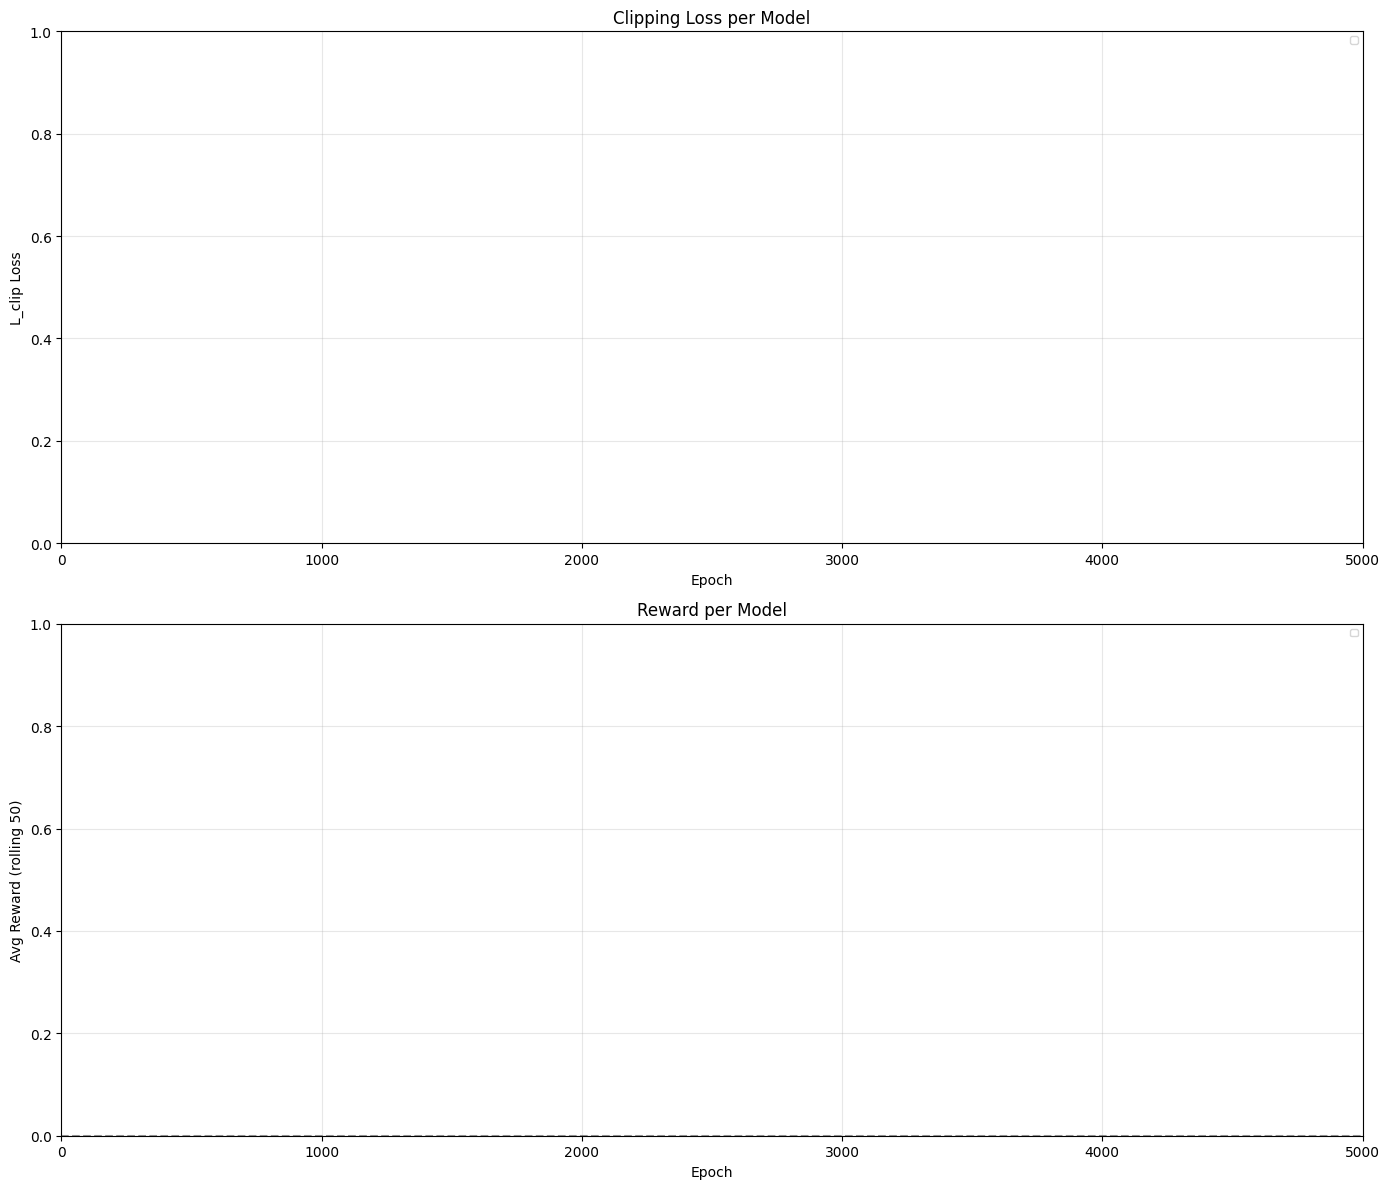

No model reached 0 avg reward within 5000 epochs.


KeyError: None

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

max_epoch = epochs


# Plot 1: Loss (L_clip) for all models
for name, data in model_dict.items():
    df = data["Stats"]
    sizes = " -> ".join([str(s[1]) for s in data["Layer specs"]])
    label = f"{name} ({data['Total layers']}L: {sizes})"
    ax1.plot(df["epoch"], df["L_clip"], label=label, alpha=0.8)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("L_clip Loss")
ax1.set_title("Clipping Loss per Model")
ax1.legend(fontsize=7, loc="best")
ax1.set_xlim(0, max_epoch)
ax1.grid(True, alpha=0.3)

# Plot 2: Rewards for all models
for name, data in model_dict.items():
    df = data["Stats"]
    sizes = " -> ".join([str(s[1]) for s in data["Layer specs"]])
    label = f"{name} ({data['Total layers']}L: {sizes})"
    # Rolling average for smoother reward curves
    ax2.plot(df["epoch"], df["reward"].rolling(50, min_periods=1).mean(), label=label, alpha=0.8)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Avg Reward (rolling 50)")
ax2.set_title("Reward per Model")
ax2.legend(fontsize=7, loc="best")
ax2.set_xlim(0, max_epoch)
ax2.axhline(y=0, color="black", linestyle="--", alpha=0.4)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Fastest to reach 0 avg reward ---
fastest_model = None
fastest_epoch = float("inf")

for name, data in model_dict.items():
    df = data["Stats"]
    rolling_reward = df["reward"].rolling(50, min_periods=1).mean()
    reached = rolling_reward[rolling_reward >= 0]
    if len(reached) > 0:
        epoch = df.loc[reached.index[0], "epoch"]
        if epoch < fastest_epoch:
            fastest_epoch = epoch
            fastest_model = name

if fastest_model:
    d = model_dict[fastest_model]
    print(f"Fastest to 0 avg reward: {fastest_model} at epoch {fastest_epoch}")
    print(f"  Layers: {d['Total layers']}, Specs: {d['Layer specs']}")
else:
    print("No model reached 0 avg reward within 5000 epochs.")

# --- Best overall score ---
best_model = None
best_reward = -float("inf")

for name, data in model_dict.items():
    max_reward = data["Stats"]["reward"].max()
    if max_reward > best_reward:
        best_reward = max_reward
        best_model = name

d = model_dict[best_model]
print(f"\nBest single-epoch reward: {best_model} with reward {best_reward:.2f}")
print(f"  Layers: {d['Total layers']}, Specs: {d['Layer specs']}")

# --- Ranking table ---
rows = []
for name, data in model_dict.items():
    df = data["Stats"]
    rolling_reward = df["reward"].rolling(50, min_periods=1).mean()
    reached = rolling_reward[rolling_reward >= 0]
    epoch_to_zero = int(df.loc[reached.index[0], "epoch"]) if len(reached) > 0 else None
    sizes = " -> ".join([str(s[1]) for s in data["Layer specs"]])

    rows.append({
        "Model": name,
        "Layers": data["Total layers"],
        "Architecture": f"8 -> {sizes}",
        "Best Reward": f"{df['reward'].max():.1f}",
        "Final Avg Reward (last 100)": f"{df['reward'].tail(100).mean():.1f}",
        "Epoch to 0 Reward": epoch_to_zero if epoch_to_zero else "Never",
    })

ranking = pd.DataFrame(rows)
ranking = ranking.sort_values("Final Avg Reward (last 100)", ascending=False, key=lambda x: pd.to_numeric(x, errors="coerce")).reset_index(drop=True)
ranking.index = ranking.index + 1
ranking.index.name = "Rank"
print("\n--- Model Ranking ---")
ranking

In [5]:
import time
print(time.time())

1770511099.39024
